<a href="https://colab.research.google.com/github/SamuelKurianRoy/LSTM-forecasting-model/blob/main/time_series_forecasting_model_using_LSTM_neural_networks_(AirPassengers).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from math import sqrt
import seaborn as sns

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Load the dataset
df = pd.read_csv('AirPassengers.csv')
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121



Dataset shape: (144, 1)

Missing values: 0

Basic statistics:
       #Passengers
count   144.000000
mean    280.298611
std     119.966317
min     104.000000
25%     180.000000
50%     265.500000
75%     360.500000
max     622.000000


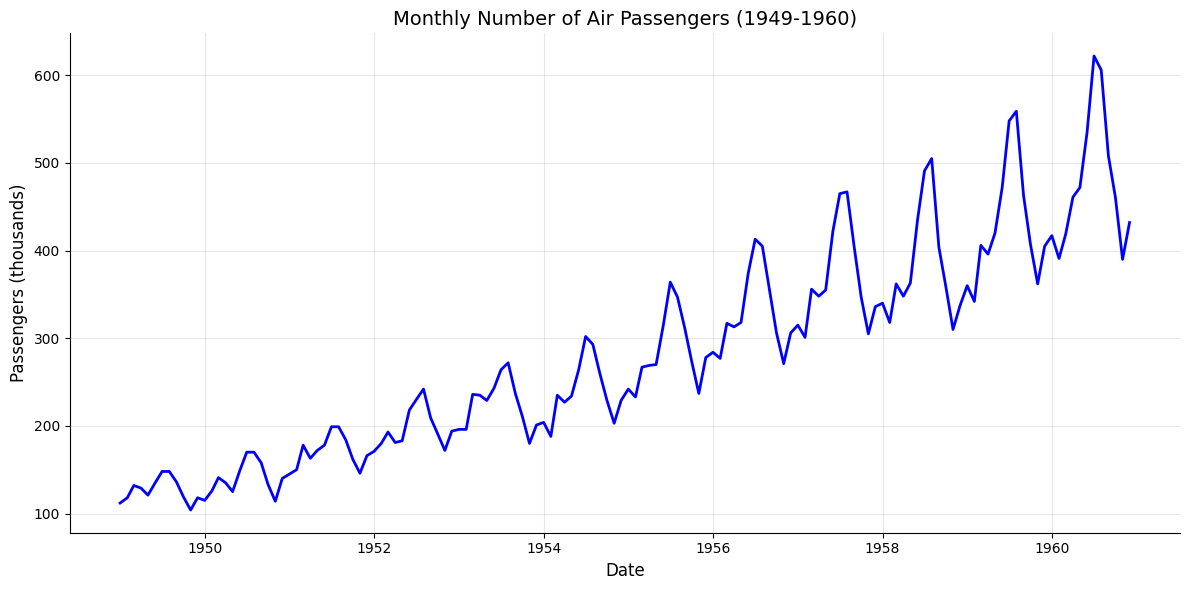

In [4]:
# Parse dates and set as index
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
print("\nDataset shape:", df.shape)

# Check for missing values
print("\nMissing values:", df.isnull().sum().sum())

# Basic statistics
print("\nBasic statistics:")
print(df.describe())

# Plot the dataset
plt.figure(figsize=(12, 6))
plt.plot(df, color='blue', linewidth=2)
plt.title('Monthly Number of Air Passengers (1949-1960)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Passengers (thousands)', fontsize=12)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('air_passengers_time_series.png')
plt.show()


In [5]:
# Data preprocessing
# Normalize data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df)

# Split the data into training and testing sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
test_size = len(data_scaled) - train_size
train_data = data_scaled[0:train_size, :]
test_data = data_scaled[train_size:len(data_scaled), :]
print(f"\nTraining data size: {train_size}, Testing data size: {test_size}")


Training data size: 115, Testing data size: 29


In [6]:
# Create sequences function
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(seq_length, len(data)):
        x.append(data[i-seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

# Sequence length (using 12 months of data to predict the next month)
seq_length = 12

# Create sequences for training and testing
X_train, y_train = create_sequences(train_data, seq_length)
X_test, y_test = create_sequences(test_data, seq_length)

# Reshape input to be [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"\nTraining sequences shape: {X_train.shape}, Target shape: {y_train.shape}")
print(f"Testing sequences shape: {X_test.shape}, Target shape: {y_test.shape}")


Training sequences shape: (103, 12, 1), Target shape: (103,)
Testing sequences shape: (17, 12, 1), Target shape: (17,)


In [7]:
# Build a more complex LSTM model
model = Sequential()
model.add(LSTM(units=64, activation='relu', return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))  # Add dropout to prevent overfitting
model.add(LSTM(units=64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
# Compile the model with adam optimizer and MSE loss
model.compile(optimizer='adam', loss='mean_squared_error')

# Print model summary
print("\nModel summary:")
model.summary()

# Train the model with early stopping and validation
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)


Model summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - loss: 0.0806 - val_loss: 0.1756
Epoch 2/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0481 - val_loss: 0.0603
Epoch 3/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0120 - val_loss: 0.0116
Epoch 4/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0184 - val_loss: 0.0145
Epoch 5/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0123 - val_loss: 0.0270
Epoch 6/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0102 - val_loss: 0.0142
Epoch 7/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0094 - val_loss: 0.0126
Epoch 8/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0080 - val_loss: 0.0118
Epoch 9/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0077 - val_loss: 0.0129
Epoch 10/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0053 - val_loss: 0.0243
Epoch 11/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0055 - val_loss: 0.0230
Epoch 12/150
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0062 - val_l

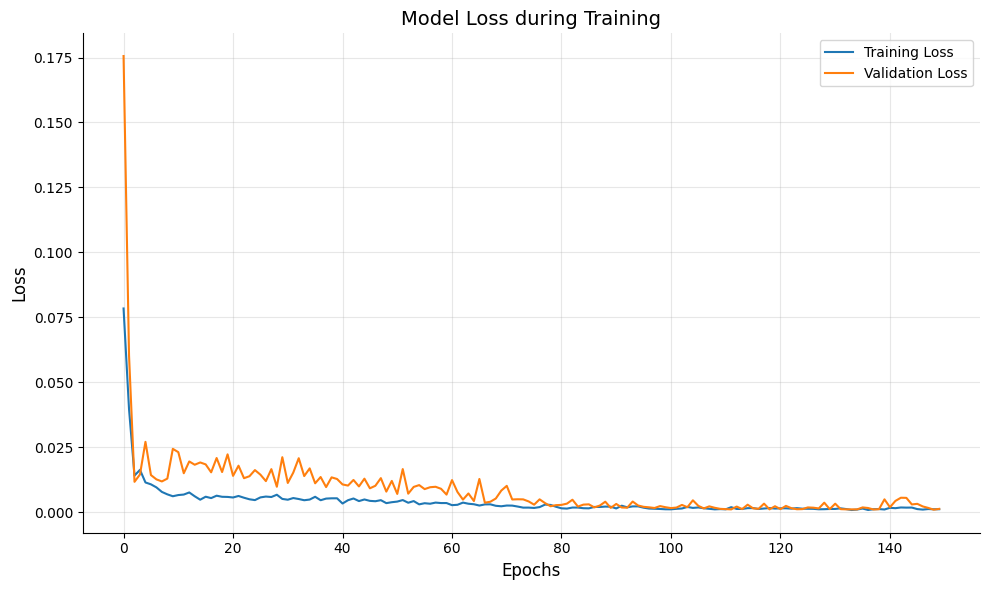

In [9]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss during Training', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('training_history.png')
plt.show()


In [10]:

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert the predictions back to original scale
train_predict = scaler.inverse_transform(train_predict)
y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
test_predict = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Create time indices for plotting
train_index = df.index[seq_length:train_size]
test_index = df.index[train_size+seq_length:len(df)]

# Calculate evaluation metrics for training set
train_rmse = sqrt(mean_squared_error(y_train_inv, train_predict))
train_mae = mean_absolute_error(y_train_inv, train_predict)
train_r2 = r2_score(y_train_inv, train_predict)
train_mape = np.mean(np.abs((y_train_inv - train_predict) / y_train_inv)) * 100

# Calculate evaluation metrics for test set
test_rmse = sqrt(mean_squared_error(y_test_inv, test_predict))
test_mae = mean_absolute_error(y_test_inv, test_predict)
test_r2 = r2_score(y_test_inv, test_predict)
test_mape = np.mean(np.abs((y_test_inv - test_predict) / y_test_inv)) * 100

# Print evaluation metrics
print("\n--- Evaluation Metrics ---")
print("\nTraining Set Metrics:")
print(f"RMSE: {train_rmse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"R² Score: {train_r2:.4f}")
print(f"MAPE: {train_mape:.2f}%")

print("\nTest Set Metrics:")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAE: {test_mae:.2f}")
print(f"R² Score: {test_r2:.4f}")
print(f"MAPE: {test_mape:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

--- Evaluation Metrics ---

Training Set Metrics:
RMSE: 13.58
MAE: 10.97
R² Score: 0.9756
MAPE: 4.64%

Test Set Metrics:
RMSE: 21.40
MAE: 17.10
R² Score: 0.9175
MAPE: 3.70%


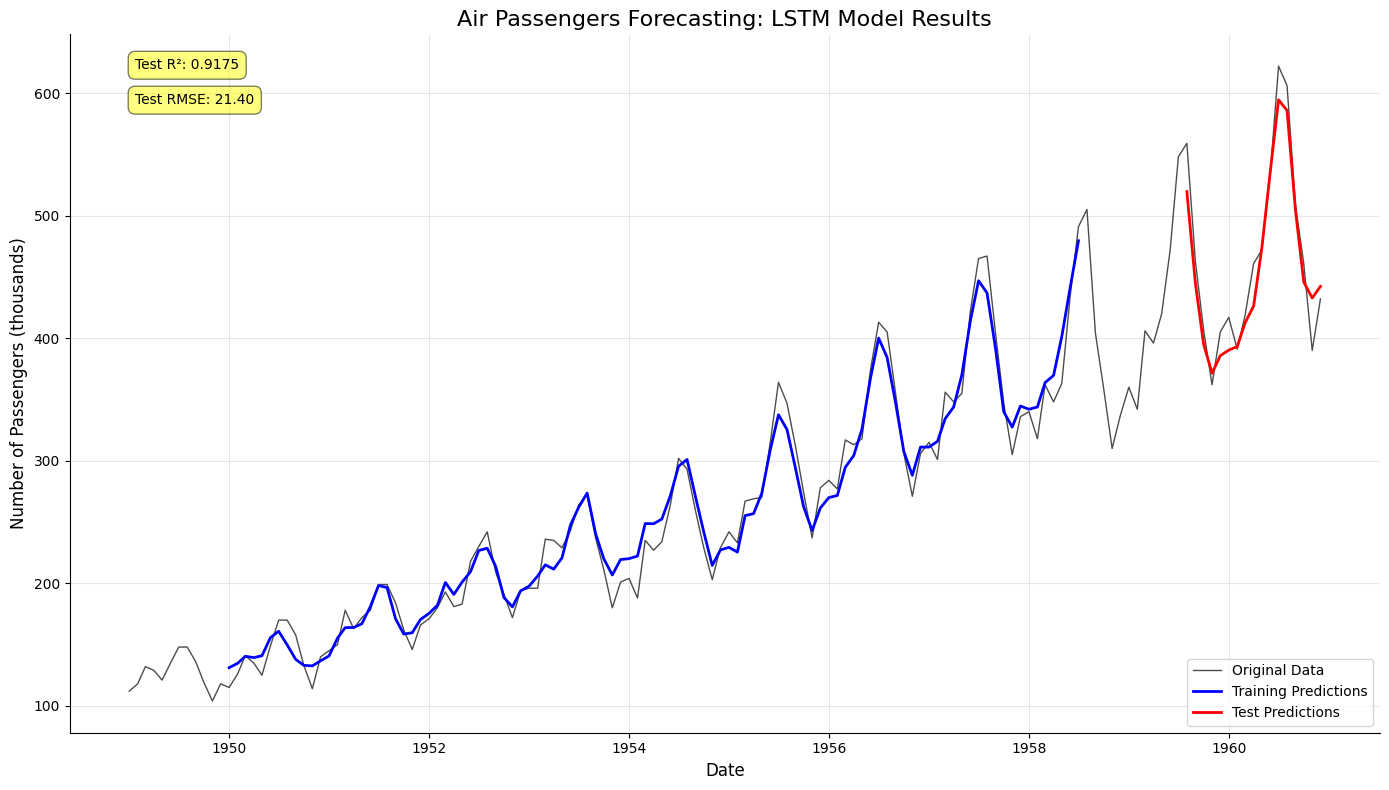

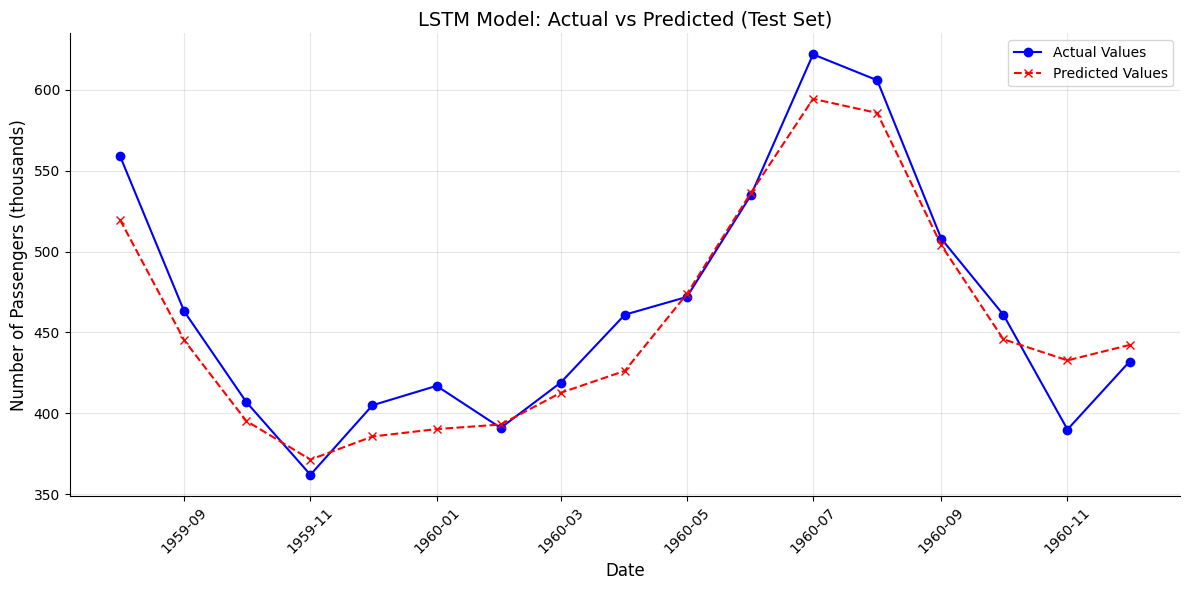

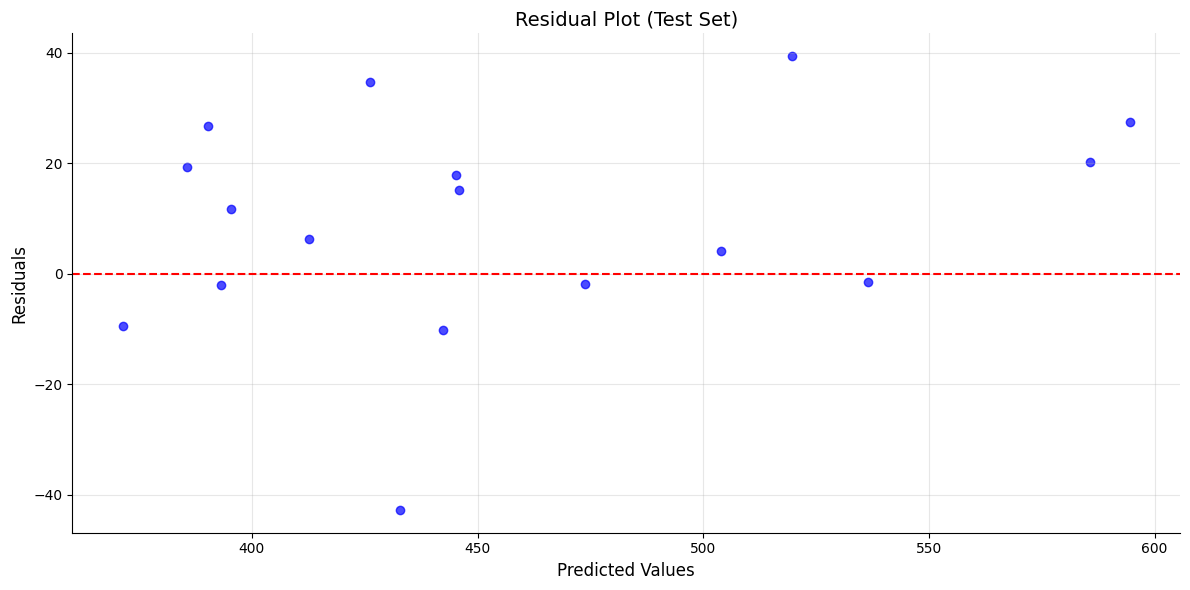

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


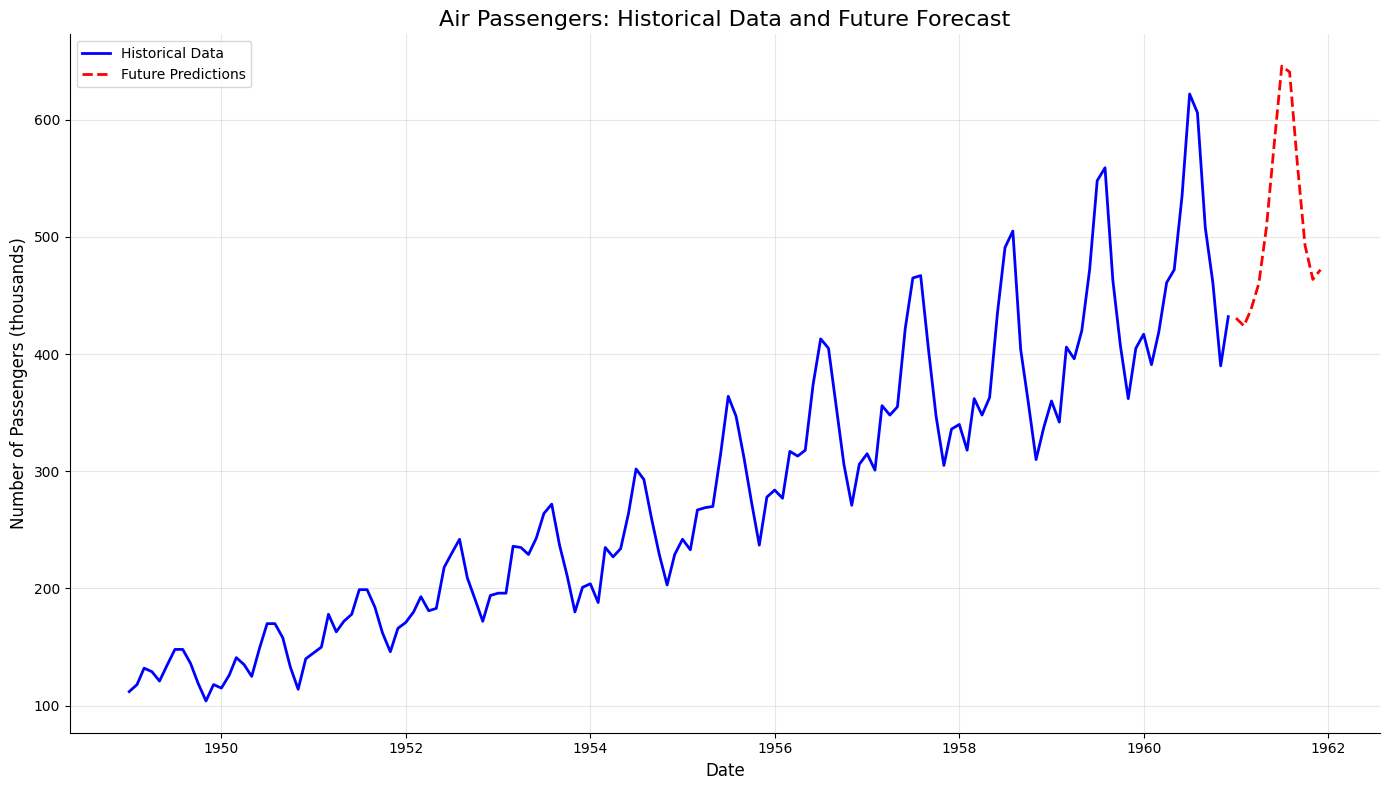


Future Predictions for the Next 12 Months:
1961-01: 431 passengers
1961-02: 424 passengers
1961-03: 438 passengers
1961-04: 460 passengers
1961-05: 508 passengers
1961-06: 579 passengers
1961-07: 646 passengers
1961-08: 641 passengers
1961-09: 561 passengers
1961-10: 493 passengers
1961-11: 464 passengers
1961-12: 472 passengers

Model saved as 'air_passengers_lstm_model.h5'


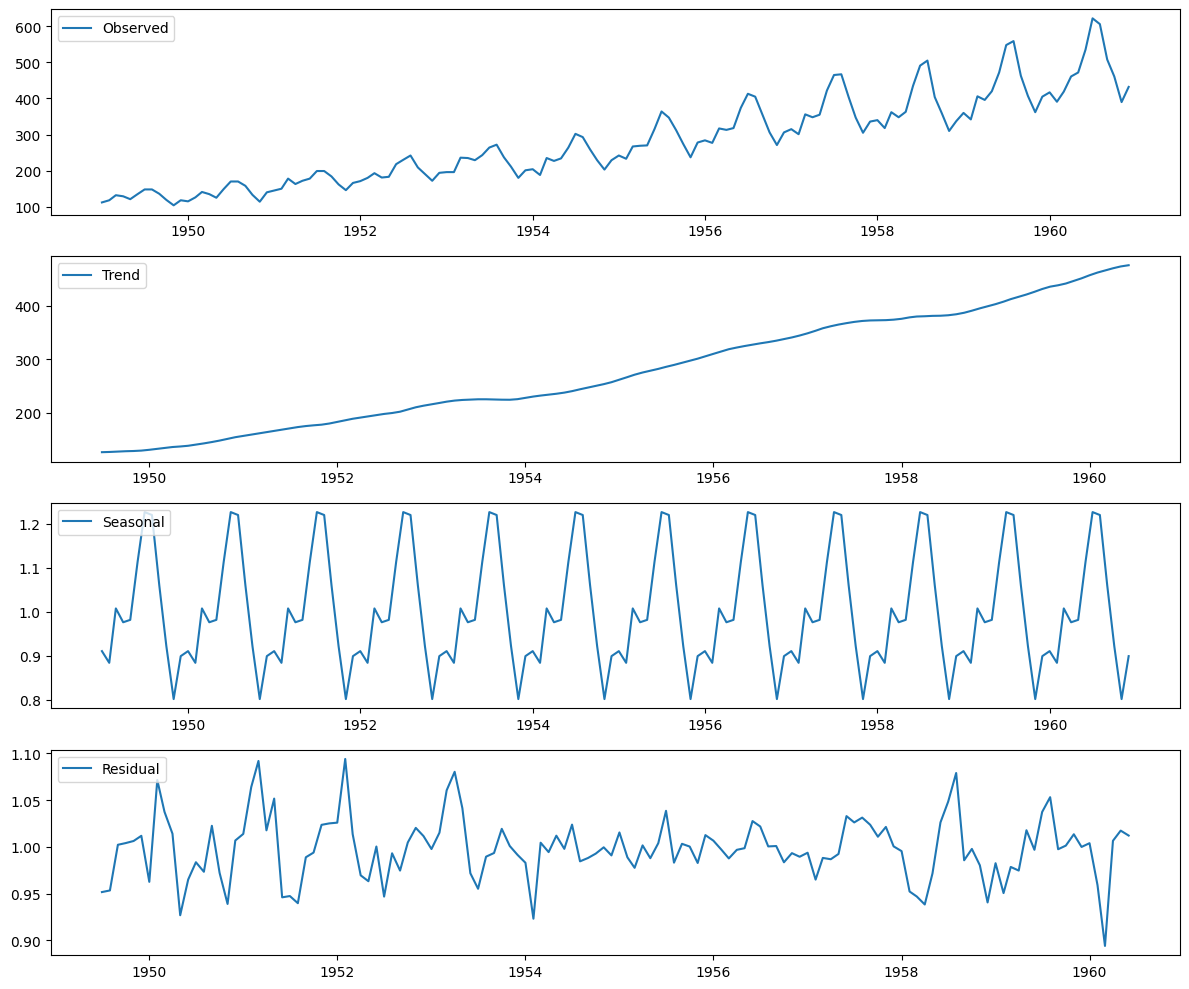

In [12]:
# Plot results
plt.figure(figsize=(14, 8))

# Plot entire original dataset
plt.plot(df, label='Original Data', color='black', alpha=0.7, linewidth=1)

# Plot training predictions
plt.plot(train_index, train_predict, label='Training Predictions', color='blue', linewidth=2)

# Plot test predictions
plt.plot(test_index, test_predict, label='Test Predictions', color='red', linewidth=2)

# Add metric annotations
plt.annotate(f'Test R²: {test_r2:.4f}', xy=(0.05, 0.95), xycoords='axes fraction',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
plt.annotate(f'Test RMSE: {test_rmse:.2f}', xy=(0.05, 0.90), xycoords='axes fraction',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.title('Air Passengers Forecasting: LSTM Model Results', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers (thousands)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('lstm_forecasting_results.png')
plt.show()

# Plot detailed comparison of actual vs predicted for test set
plt.figure(figsize=(12, 6))
plt.plot(test_index, y_test_inv, label='Actual Values', marker='o', markersize=6, linestyle='-', color='blue')
plt.plot(test_index, test_predict, label='Predicted Values', marker='x', markersize=6, linestyle='--', color='red')
plt.title('LSTM Model: Actual vs Predicted (Test Set)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers (thousands)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.savefig('actual_vs_predicted_test.png')
plt.show()

# Create residual plot
residuals = y_test_inv - test_predict
plt.figure(figsize=(12, 6))
plt.scatter(test_predict, residuals, color='blue', alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Test Set)', fontsize=14)
plt.xlabel('Predicted Values', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('residual_plot.png')
plt.show()

# Generate future predictions for the next 12 months
last_sequence = data_scaled[-seq_length:].reshape(1, seq_length, 1)
future_predictions = []

for _ in range(12):  # Predict next 12 months
    next_pred = model.predict(last_sequence)
    future_predictions.append(next_pred[0, 0])
    # Update sequence for next prediction - fix dimensionality issue
    # Remove oldest prediction and add newest to the end
    last_sequence = np.append(last_sequence[:, 1:, :],
                             next_pred.reshape(1, 1, 1),
                             axis=1)

# Inverse transform future predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Create future dates for the next 12 months
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# Plot with future predictions
plt.figure(figsize=(14, 8))
plt.plot(df.index, df, label='Historical Data', color='blue', linewidth=2)
plt.plot(future_dates, future_predictions, label='Future Predictions', color='red', linewidth=2, linestyle='--')
plt.title('Air Passengers: Historical Data and Future Forecast', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Passengers (thousands)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('future_forecast.png')
plt.show()

# Print future predictions
print("\nFuture Predictions for the Next 12 Months:")
for date, pred in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m')}: {pred[0]:.0f} passengers")

# Save the model
model.save('air_passengers_lstm_model.h5')
print("\nModel saved as 'air_passengers_lstm_model.h5'")

# Additional analysis: Seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative', period=12)

# Plot decomposition
fig = plt.figure(figsize=(12, 10))
plt.subplot(411)
plt.plot(decomposition.observed, label='Observed')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('seasonal_decomposition.png')
plt.show()